# Preprocesamiento de Datos en Aprendizaje Automático


Una vez que se ha realizado el análisis exploratorio, es fundamental limpiar y normalizar los datos para garantizar que estén en la mejor forma posible para su uso en modelos de aprendizaje automático. Esta fase incluye:




## Limpieza de Datos en Aprendizaje Automático

A menudo, los datos crudos contienen errores, valores faltantes, duplicados y otros problemas que pueden afectar negativamente el rendimiento de los modelos y la confiabilidad de los análisis. Este proceso asegura que los datos utilizados en las siguientes etapas de modelado y análisis sean consistentes, precisos y completos.

### Impacto en el Rendimiento del Modelo

- **Precisión y Fiabilidad**: La calidad de los datos de entrada afecta directamente la precisión y fiabilidad de los modelos. Si los datos están sucios o incompletos, los modelos pueden generar resultados inexactos, lo que lleva a conclusiones erróneas.
- **Resultados Engañosos**: Datos de baja calidad pueden producir resultados que no reflejan la realidad del fenómeno estudiado, distorsionando el análisis y comprometiendo la toma de decisiones.

### Eficiencia

- **Ahorro de Tiempo y Recursos**: Limpiar los datos al principio del proceso de análisis ahorra tiempo y recursos computacionales en etapas posteriores. Datos limpios reducen la necesidad de volver a procesar o reanalizar la información.
- **Menor Retrabajo**: Abordar problemas de calidad de datos desde el principio minimiza la necesidad de correcciones posteriores, permitiendo un flujo de trabajo más eficiente.

El siguiente ejemplo ilustra el impacto de la limpieza de datos mediante la comparación de los resultados de un modelo de regresión. Se muestra cómo el modelo se comporta cuando se entrena primero con datos sin limpiar y luego con los datos ya limpios.

In [ ]:
# Librerias necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Paso 1: Crear un dataset
np.random.seed(42)
data = {
    'Feature1': np.random.normal(0, 1, 100),
    'Feature2': np.random.normal(0, 1, 100),
    'Target': np.random.normal(0, 1, 100)
}

# Introducir missing values y duplicados
df = pd.DataFrame(data)
df.loc[::10, 'Feature1'] = np.nan  # Introduce missing values
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)  # Introduce a duplicate row

# Paso 2: Entrenar el modelo sin limpiar los datos por completo
# Imputar con la media los valores perdidos (Este paso debe realizarse ya que el modelo no recibe valores NAN)
X = df[['Feature1', 'Feature2']].fillna(df.mean())
y = df['Target']

# Dividir los datos en el conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model_unclean = LinearRegression()
model_unclean.fit(X_train, y_train)
y_pred_unclean = model_unclean.predict(X_test)
mse_unclean = mean_squared_error(y_test, y_pred_unclean)
print(f'MSE sin remover duplicados: {mse_unclean}')

# Paso 3: Limpiar los datos removiendo los duplicados
df_cleaned = df.drop_duplicates().fillna(df.mean())

# Paso 4: Entrenar el modelo luego de limpiar los datos
X_cleaned = df_cleaned[['Feature1', 'Feature2']]
y_cleaned = df_cleaned['Target']
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)
model_cleaned = LinearRegression()
model_cleaned.fit(X_train_cleaned, y_train_cleaned)
y_pred_cleaned = model_cleaned.predict(X_test_cleaned)
mse_clean = mean_squared_error(y_test_cleaned, y_pred_cleaned)
print(f'MSE luego de limpiar los datos: {mse_clean}')

# Paso 5: Comparar el resultados
print("\nComparison of Model Performance:")
print(f"Mean Squared Error without data cleaning (with imputation only): {mse_unclean:.4f}")
print(f"Mean Squared Error after data cleaning (imputation + removing duplicates): {mse_clean:.4f}")




MSE sin remover duplicados: 0.8924061535803095
MSE luego de limpiar los datos: 0.5723742199901609

Comparison of Model Performance:
Mean Squared Error without data cleaning (with imputation only): 0.8924
Mean Squared Error after data cleaning (imputation + removing duplicates): 0.5724


## Problemas Comunes en los Set de Datos

En el preprocesamiento de datos, uno de los principales desafíos es manejar problemas comunes que pueden afectar la calidad del análisis y los resultados del modelo. En esta sección, se exploraran algunos de los problemas más comunes que pueden encontrarse en un dataset y pueden afectar la calidad de los datos y, por lo tanto, la fiabilidad de cualquier análisis o modelo.

El siguiente ejemplo muestra como se pueden identificar y visualizar algunos de los problemas comunes en los datos, tales como valores faltantes, duplicados y outliers.


In [ ]:
# Librerias
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset Titanic desde Seaborn
df_titanic = sns.load_dataset('titanic')
df_titanic.head()




,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df_titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df_titanic.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [ ]:
df_titanic.isnull().sum() / len(df_titanic)

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,0.198653
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.002245
class,0.000000
who,0.000000


## Duplicados

Los registros duplicados ocurren por entradas multiples para la misma entidad y pueden sesgar los resultados del análisis, para ello se utilizan funciones como **`duplicates`** de la libreria pandas para identificar las filas duplicadas y posteriormente se utiliza **`drop_duplicates`** para eliminar dichos duplicados. Es importante asegurarse de que los duplicados son realmente redundantes y no medidas repetidas importantes en el contexto del analisis.

En este ejemplo, se va a utilizar la **imputación con la media y moda** para los valores faltantes en la columna  y **`drop_duplicates**` para los duplicados.

```
# Eliminar filas duplicadas
df.drop_duplicates(inplace=True)
```

## Imputación de Valores Faltantes

En ciencia de datos, los valores faltantes son datos que no están disponibles o no fueron registrados en el conjunto de datos. Estos valores pueden aparecer por diversas razones, como errores en la recolección de datos, la omisión de respuestas en encuestas o fallos en la transmisión de datos. La presencia de valores faltantes puede afectar la calidad del análisis y, por lo tanto, es crucial manejar estos valores de manera adecuada antes de proceder con el modelado.

### ¿Qué es la Imputación?

La imputación es el proceso de sustituir los valores faltantes en un conjunto de datos por otros valores razonables. Este paso es fundamental para evitar que los modelos de aprendizaje automático o los análisis estadísticos se vean comprometidos por la falta de datos.

### Métodos Comunes de Imputación Univariada.

Existen varios métodos para imputar valores faltantes, entre ellos:

1. **Imputación con la Media:**
   - Se reemplazan los valores faltantes con la media de la columna en la que se encuentran los datos faltantes. Este método es simple y efectivo, especialmente cuando los datos están distribuidos de manera cercana a la normalidad.

2. **Imputación con la Mediana:**
   - Similar a la imputación con la media, pero en lugar de usar la media, se usa la mediana. Es útil cuando la variable tiene una distribución sesgada o tiene outliers.

3. **Imputación con la Moda:**
   - Este método sustituye los valores faltantes por el valor más frecuente en la columna, y se utiliza comúnmente para variables categóricas.


**Si los valores faltantes son menos del 1% del total:**
   - **Eliminar filas o columnas:** Si el porcentaje de valores faltantes es muy bajo (por ejemplo, menos del 1%), una opción válida es eliminar las filas o columnas que contienen esos valores. Esta opción es viable cuando la pérdida de datos no afectará significativamente el análisis.

**Si los valores faltantes son significativos (por ejemplo, más del 30%):**
   - **Imputación avanzada:** Para porcentajes altos de valores faltantes, se puede considerar el uso de métodos más avanzados como la imputación por regresión, KNN o incluso la creación de un modelo predictivo para estimar los valores faltantes.




In [ ]:
# Identificar valores perdidos
print("Missing values per column:")
print(df_titanic.isnull().sum())


Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


<Figure size 1000x600 with 0 Axes>

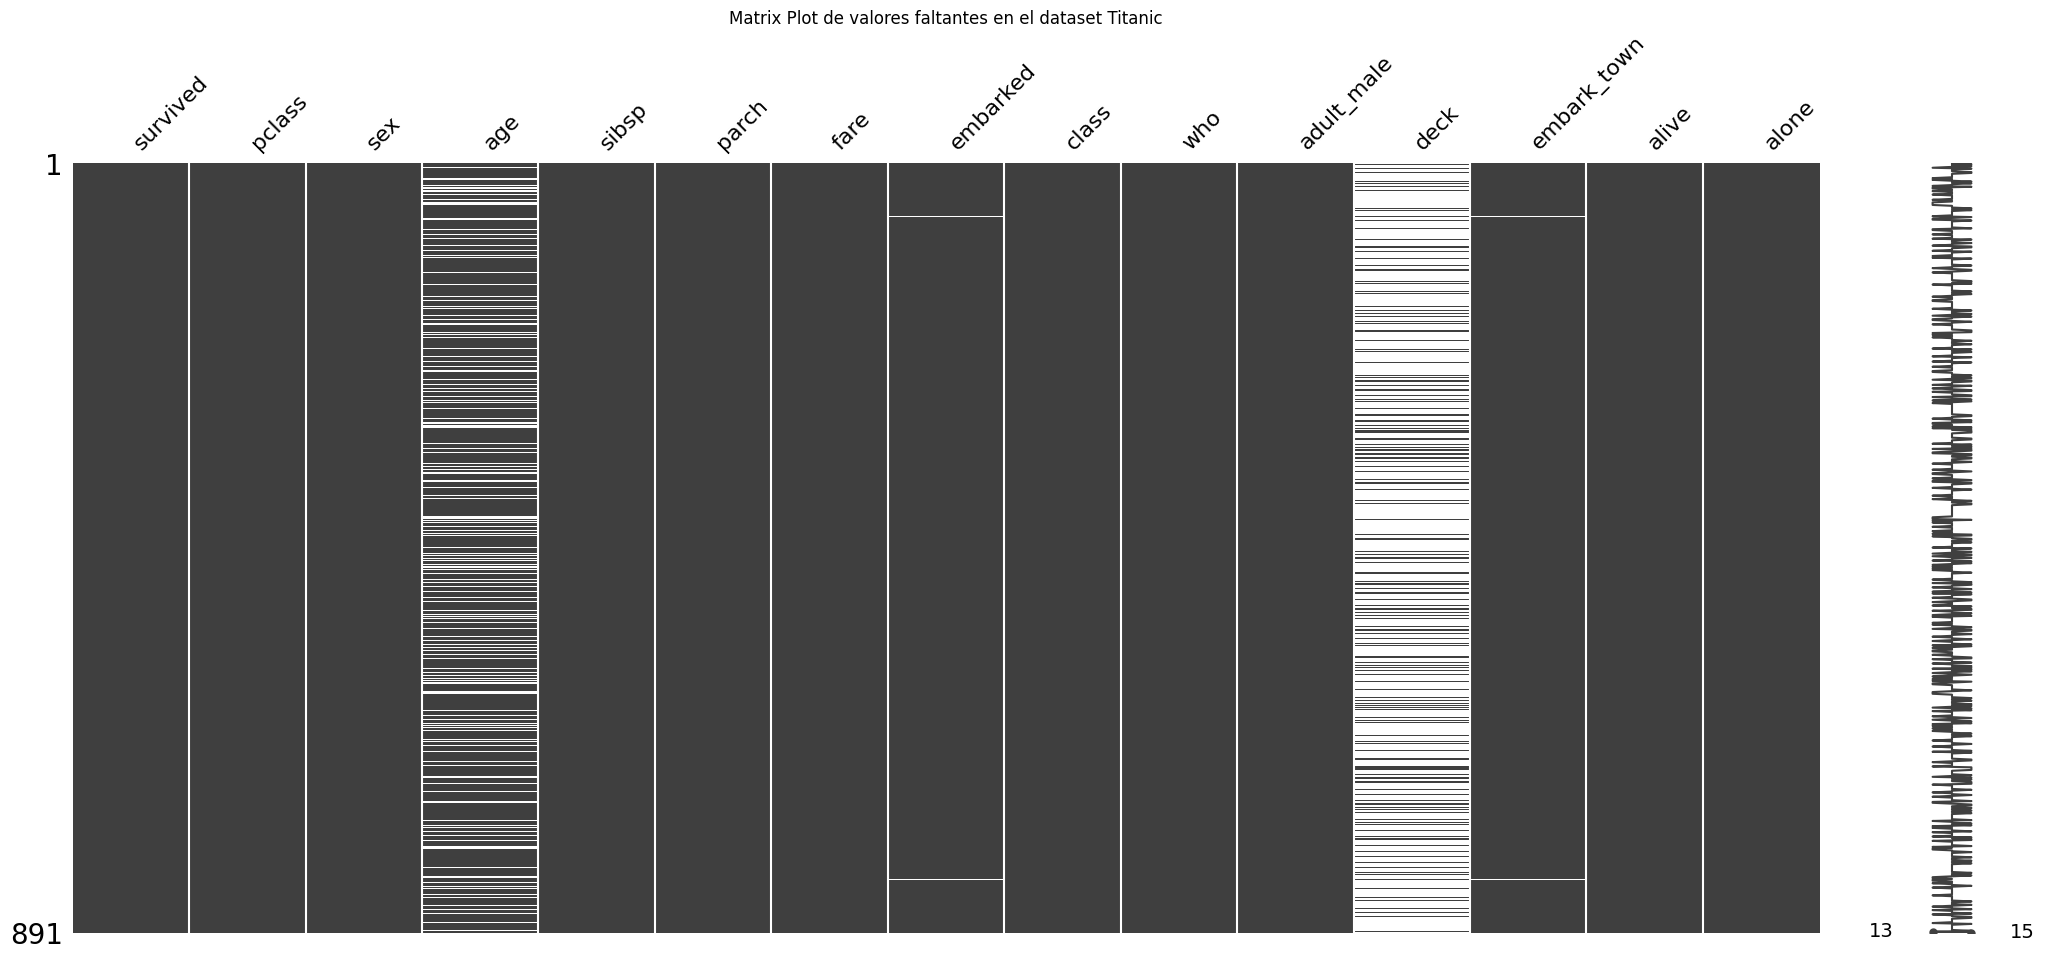

In [ ]:
# Importar librerías necesarias
import missingno as msno

# Crear un matrix plot para visualizar los valores faltantes
plt.figure(figsize=(10, 6))
msno.matrix(df_titanic)
plt.title('Matrix Plot de valores faltantes en el dataset Titanic')
plt.show()


Podemos realizar la siguientes operaciones columna por columna.

In [ ]:
# Imputar valores faltantes en la columna 'age' con la media

df_titanic1 = df_titanic.copy()

df_titanic1['age'].fillna(df_titanic1['age'].mean(), inplace=True)

# Imputar valores faltantes en la columna 'embarked' con la moda

df_titanic1['embarked'].fillna(df_titanic1['embarked'].mode()[0], inplace=True)
# Imputar valores faltantes en la columna 'deck' con la moda

df_titanic1['deck'].fillna(df_titanic1['deck'].mode()[0], inplace=True)
# Imputar valores faltantes en la columna 'embark_town' con la moda

df_titanic1['embark_town'].fillna(df_titanic1['embark_town'].mode()[0], inplace=True)

# Eliminar filas duplicadas

df_titanic1.drop_duplicates(inplace=True)

# Verificar la eliminación de duplicados y valores faltantes



In [ ]:
df_titanic1.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
df_titanic1.duplicated().sum()

0

Ahora vamos a repetir el código anterior usando módulos de `Sklearn`


In [ ]:
# Importar las librerías necesarias
import seaborn as sns
import pandas as pd
from sklearn.impute import SimpleImputer

# Cargar el dataset Titanic desde Seaborn
df_titanic2 = df_titanic.copy()


# Imputar valores faltantes en la columna 'age' con la media

mean_imputer = SimpleImputer(strategy='mean')


df_titanic2['age'] = mean_imputer.fit_transform(df_titanic2[['age']])

# Imputar valores faltantes en las columnas 'embarked', 'deck' y 'embark_town' con la moda

mode_imputer = SimpleImputer(strategy='most_frequent')

df_titanic2[['embarked', 'deck', 'embark_town']] = mode_imputer.fit_transform(df_titanic2[['embarked', 'deck', 'embark_town']])

# Eliminar filas duplicadas

df_titanic2.drop_duplicates(inplace=True)

# Verificar la eliminación de duplicados y valores faltantes
print("\nNumber of duplicate rows after cleaning:")
print(df_titanic2.duplicated().sum())

print("\nMissing values after imputations:")
print(df_titanic2.isnull().sum())


Number of duplicate rows after cleaning:
0

Missing values after imputations:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


# Imputación Multivariada

A diferencia de la imputación univariada, que utiliza solo una variable para estimar los valores faltantes, la imputación multivariada utiliza las relaciones entre varias variables para generar estimaciones más precisas.

### Imputación de Datos con MICE y KNN

Cuando trabajamos con conjuntos de datos reales, es común encontrar valores faltantes. Estos valores faltantes pueden introducir sesgos y reducir la calidad de los modelos predictivos si no se manejan adecuadamente. Dos técnicas avanzadas para imputar valores faltantes son **MICE (Multiple Imputation by Chained Equations)** y **KNN (K-Nearest Neighbors Imputer)**. A continuación, se explica cómo funcionan estos métodos.

---

### MICE (Multiple Imputation by Chained Equations)

**MICE** es una técnica de imputación multivariada que se utiliza para manejar valores faltantes en los datos. A diferencia de los métodos simples, como la imputación con la media o la moda, MICE utiliza un enfoque iterativo que toma en cuenta las relaciones entre todas las variables del conjunto de datos. Este método es especialmente útil cuando los valores faltantes se distribuyen de manera no aleatoria y dependen de otras variables en el conjunto de datos.

#### ¿Cómo funciona MICE?

1. **Inicialización**: El proceso comienza imputando valores iniciales a los datos faltantes. Esto se puede hacer utilizando un método simple, como la imputación por la media o la moda.

2. **Imputación Iterativa**:
   - MICE trata cada variable con valores faltantes como una variable objetivo en un modelo de regresión.
   - En cada iteración, MICE selecciona una variable con valores faltantes y ajusta un modelo de regresión para predecir los valores faltantes basándose en todas las demás variables (incluyendo las que ya han sido imputadas).
   - Se reemplazan los valores faltantes en esta variable con las predicciones obtenidas del modelo de regresión.

3. **Ciclo a través de todas las variables**: Este proceso se repite iterativamente para todas las variables con valores faltantes. El ciclo continúa hasta que las imputaciones convergen, es decir, hasta que los valores imputados ya no cambian significativamente de una iteración a otra.

4. **Múltiples imputaciones**: Una característica importante de MICE es que se pueden generar múltiples conjuntos de datos imputados, lo que permite capturar la incertidumbre en la imputación de valores faltantes. Luego, se puede promediar o combinar los resultados de estos múltiples conjuntos de datos para obtener las estimaciones finales.

#### Ventajas y Aplicaciones

- **Capacidad multivariada**: MICE puede manejar tanto variables numéricas como categóricas, y es capaz de capturar las relaciones complejas entre ellas.
- **Incertidumbre**: La posibilidad de generar múltiples imputaciones permite reflejar la incertidumbre inherente en la estimación de los valores faltantes.
- **Aplicaciones**: Es ideal para estudios donde los valores faltantes no son al azar (MAR - Missing At Random) y se necesita un análisis robusto que tome en cuenta todas las variables del conjunto de datos.

---

### KNN (K-Nearest Neighbors Imputer)

**KNN Imputer** es otro método popular para imputar valores faltantes. A diferencia de MICE, que se basa en modelos de regresión, KNN utiliza la proximidad en un espacio multidimensional para determinar los valores faltantes. Este método es sencillo de entender y aplicar, y es particularmente útil cuando se cree que los valores faltantes están relacionados con las observaciones más cercanas en términos de similitud.

#### ¿Cómo funciona KNN Imputer?

1. **Definición de Vecinos**:
   - Para cada valor faltante en el conjunto de datos, el KNN Imputer identifica los \( k \) vecinos más cercanos (observaciones completas) en un espacio definido por las demás variables.
   - La distancia entre las observaciones se puede calcular utilizando diferentes métricas, como la distancia euclidiana, Manhattan, etc.

2. **Imputación**:
   - Una vez identificados los \( k \) vecinos más cercanos, el valor faltante se imputa utilizando la media (para variables numéricas) o la moda (para variables categóricas) de los valores correspondientes en estos vecinos.
   - Este proceso se repite para cada valor faltante en el conjunto de datos.

3. **Ventanas Deslizantes**: KNN considera sólo un subconjunto de datos, lo que lo hace especialmente adecuado para conjuntos de datos grandes o cuando los valores faltantes se distribuyen de manera esparcida.

#### Ventajas y Aplicaciones

- **Simplicidad**: KNN es fácil de entender e implementar, y no requiere suposiciones complejas sobre la distribución de los datos.
- **Preservación de relaciones no lineales**: Este método es eficaz para mantener las relaciones no lineales entre variables.
- **Aplicaciones**: Es útil cuando se cree que los valores faltantes son similares a los de sus vecinos más cercanos, lo cual es común en datos estructurados y con dependencia espacial o temporal.

---
### Comparación de MICE y KNN Imputer

- **Complejidad vs. Simplicidad**: MICE es más complejo y considera relaciones entre todas las variables, lo que lo hace potente pero computacionalmente más costoso. KNN es más simple y directo, pero puede no capturar relaciones complejas tan bien como MICE.
- **Capacidad de manejo de variables categóricas**: Ambos métodos pueden imputar variables categóricas, aunque MICE suele requerir una codificación previa, mientras que KNN maneja directamente los valores imputados basándose en la similitud.
- **Escalabilidad**: KNN puede ser menos escalable en conjuntos de datos muy grandes, ya que requiere calcular distancias para cada imputación. MICE, aunque más complejo, puede escalar mejor en términos de su capacidad de manejar relaciones complejas en datasets de tamaño moderado.



In [ ]:
# Importar librerías necesarias
import seaborn as sns
import pandas as pd

from sklearn.experimental import enable_iterative_imputer  # Necesario para activar IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import numpy as np

# Cargar el dataset Titanic desde Seaborn
df_titanic1 = sns.load_dataset('titanic')

# Mostrar los valores faltantes antes de la imputación
print("Valores faltantes antes de la imputación:")
print(df_titanic1.isnull().sum())

# ==========================
# Estrategia 1: Imputación Multivariada con IterativeImputer
# ==========================

iterative_imputer = IterativeImputer(random_state=42)

# seleccionar las variables que son numericas
numeric_cols = df_titanic1.select_dtypes(include=[np.number]).columns

df_titanic1[numeric_cols] = iterative_imputer.fit_transform(df_titanic1[numeric_cols])

print("Valores faltantes después de la imputación:")
print(df_titanic1.isnull().sum())

Valores faltantes antes de la imputación:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Valores faltantes después de la imputación:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# Intenten hacer la imputación parar las variables categoricas !!


In [ ]:
# Cargar el dataset Titanic desde Seaborn
df_titanic2 = sns.load_dataset('titanic')



# ==========================
# Estrategia 2: Imputación Multivariada con KNNImputer
# ==========================

knn_imputer = KNNImputer(n_neighbors=5)
df_titanic2[numeric_cols] = knn_imputer.fit_transform(df_titanic2[numeric_cols])

print("Valores faltantes después de la imputación:")
print(df_titanic2.isnull().sum())

Valores faltantes después de la imputación:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
df_titanic1.dtypes

,0
survived,float64
pclass,float64
sex,object
age,float64
sibsp,float64
parch,float64
fare,float64
embarked,object
class,category
who,object


In [ ]:
df_titanic1['deck'].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [ ]:
df_titanic1['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
df_titanic1['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)

**Comentarios**

Como se observa ambas estrategias funcionan para los datos numerico y no consiguen realizar la imputación para las colmnas categoricas. Para realizar esta labor debemos transformar las variables categoricas a su equivalente numerico.

Por complitud pondremos el codigo aqui abajo incluyendo la transformación de las variables categoricas.

In [ ]:
# Importar librerías necesarias
from sklearn.preprocessing import OrdinalEncoder

# Cargar el dataset Titanic desde Seaborn
df_titanic2 = sns.load_dataset('titanic')

# Mostrar los valores faltantes antes de la imputación
print("Valores faltantes antes de la imputación:")
print(df_titanic2.isnull().sum())

# ==========================
# Codificación de Variables Categóricas usando OrdinalEncoder
# ==========================


# ==========================
# Estrategia 1: Imputación Multivariada con MICE (IterativeImputer)
# ==========================



# ==========================
# Estrategia 2: Imputación Multivariada con KNNImputer
# ==========================



Valores faltantes antes de la imputación:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Valores faltantes después de IterativeImputer (MICE):
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

Valores faltantes después de KNNImputer:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


## Outliers Unidimensionales

Los outliers son valores que están significativamente alejados del resto de los datos. Pueden ser el resultado de errores en la recolección de datos, entradas incorrectas, o pueden ser datos reales que reflejan una variabilidad extrema.

El proceso de manejo de outliers implica, primero, identificar los valores atípicos utilizando dos métodos comunes:




### Rango Intercuartil (IQR)
Este método define límites superior e inferior basados en los cuartiles de la distribución. Los valores que caen fuera de estos límites se consideran outliers.

Una estrategia común para manejar estos outliers es reemplazarlos con la mediana de la columna, una medida robusta que no se ve afectada por los valores extremos. Este enfoque ayuda a suavizar la influencia de los outliers en los modelos y análisis subsecuentes, preservando la integridad de la distribución original sin eliminar completamente los datos.

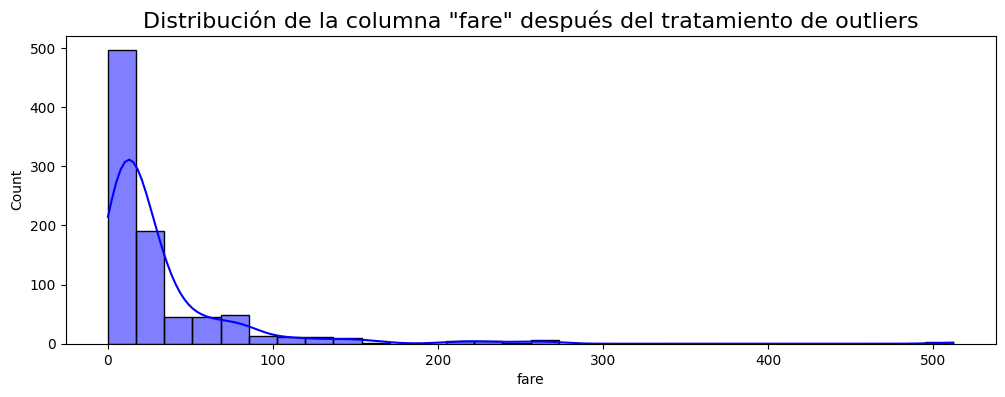

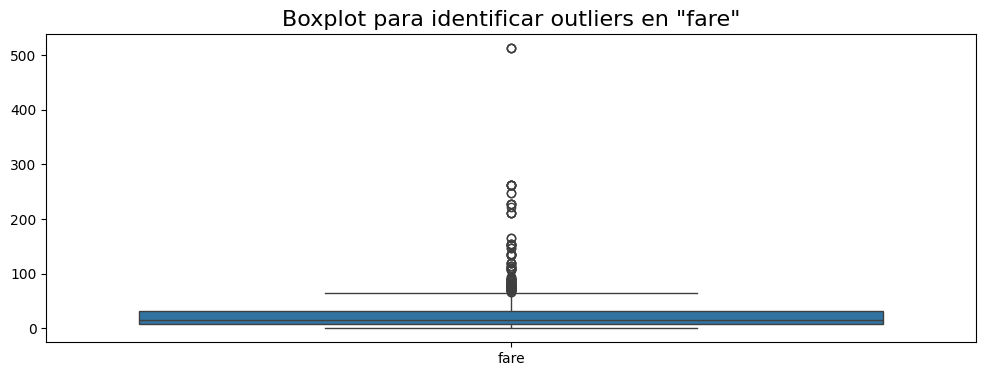

In [ ]:
# Visualización inicial para detectar outliers en la columna 'fare'
plt.figure(figsize=(12, 4))
sns.histplot(df_titanic1['fare'], bins=30, kde=True, color='blue')
plt.title('Distribución de la columna "fare" después del tratamiento de outliers', fontsize=16)
plt.show()


# Visualización inicial para detectar outliers en la columna 'fare'
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_titanic1[['fare']])
plt.title('Boxplot para identificar outliers en "fare"', fontsize=16)
plt.show()



Outliers en la columna 'fare':
116


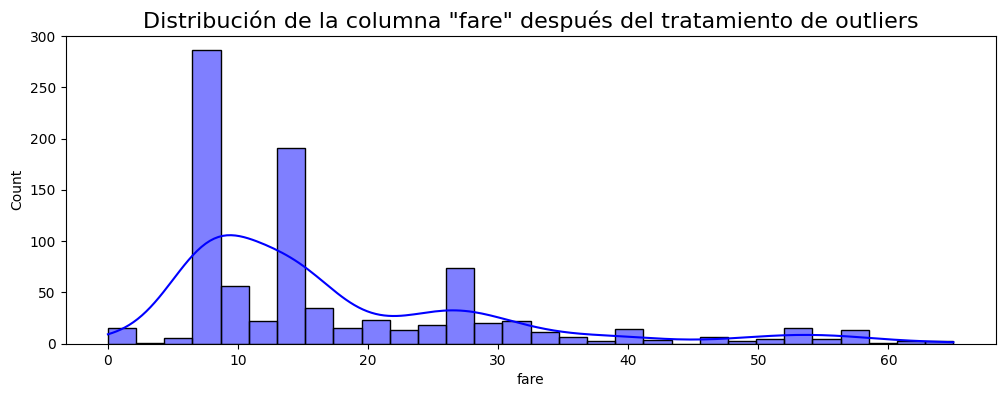

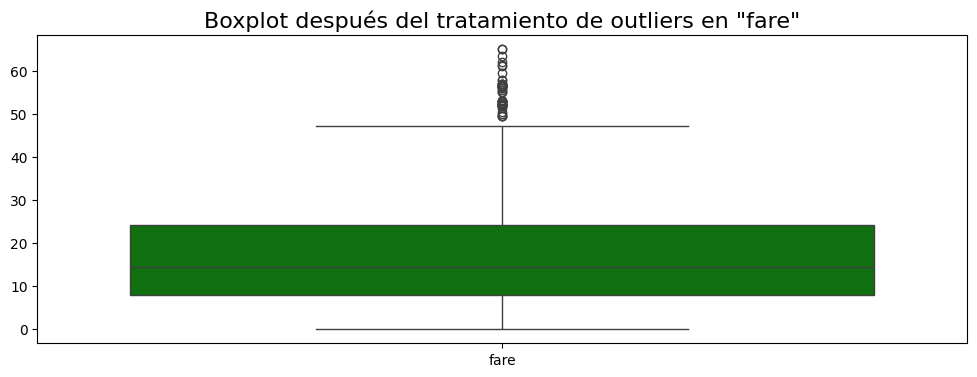

In [ ]:

df_median = df_titanic1.copy()

# Calcular los cuartiles y el rango intercuartil (IQR)

Q1 = df_median['fare'].quantile(0.25)
Q3 = df_median['fare'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para detectar outliers
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

# Filtrar los outliers
outliers = df_median[(df_median['fare'] < Lower_Bound) | (df_median['fare'] > Upper_Bound)]
print("Outliers en la columna 'fare':")
print(len(outliers))

# Manejo de outliers: Reemplazar los outliers con la mediana de la columna 'fare'
fare_median = df_median['fare'].median()

df_median['fare'] = df_median['fare'].apply(lambda x: fare_median if x > Upper_Bound else x)
df_median['fare'] = df_median['fare'].apply(lambda x: fare_median if x < Lower_Bound else x)


# Verificación post-tratamiento: Comparar distribuciones antes y después
plt.figure(figsize=(12, 4))
sns.histplot(df_median['fare'], bins=30, kde=True, color='blue')
plt.title('Distribución de la columna "fare" después del tratamiento de outliers', fontsize=16)
plt.show()

# Verificación post-tratamiento: Visualizar el boxplot después del tratamiento
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_median[['fare']], color='green')
plt.title('Boxplot después del tratamiento de outliers en "fare"', fontsize=16)
plt.show()


### Z-Score
Esta técnica mide cuántas desviaciones estándar se encuentra un valor de la media. Generalmente, un valor se considera un outlier si su Z-Score es mayor que 3 o menor que -3. El Z-Score es útil para detectar outliers en datos que siguen una distribución normal.

Finalmente, se revisa el impacto de este tratamiento mediante visualizaciones como boxplots y histogramas para asegurar que los outliers han sido manejados de manera adecuada.

Outliers en la columna 'fare':
38


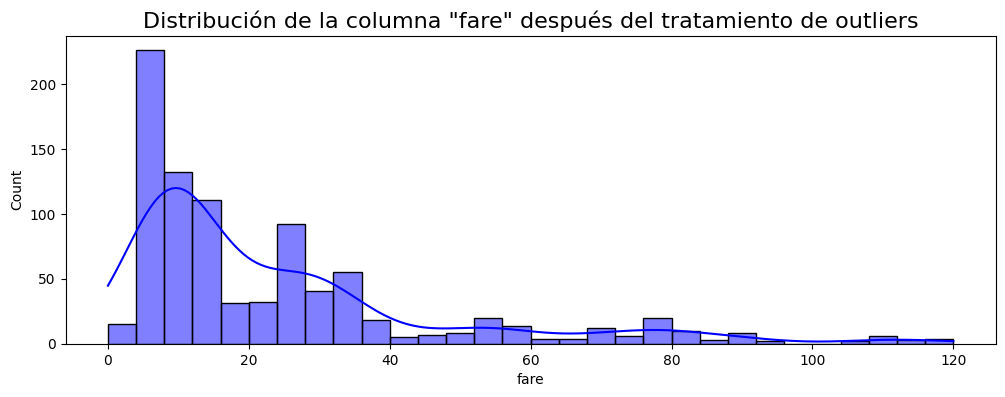

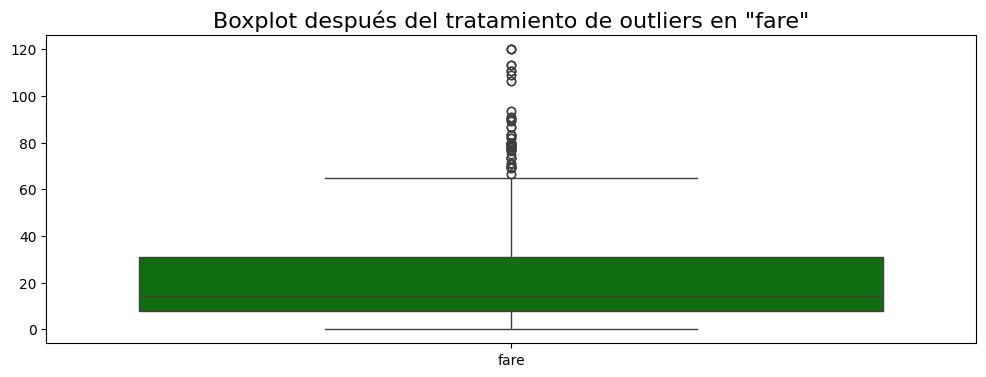

In [ ]:
from re import T
# Libreria Zcore
from scipy.stats import zscore
# Crear una copia del dataframe original para trabajar con Z-Score
df_zscore = df_titanic1.copy()

# Calcular el Z-Score para la columna 'fare'
df_zscore['fare_zscore'] = zscore(df_zscore['fare'])

# Definir el umbral para considerar un valor como outlier (e.g., Z-Score mayor que 3)
threshold = 2

outliers = df_zscore[abs(df_zscore['fare_zscore']) > threshold]
print("Outliers en la columna 'fare':")
print(len(outliers))


# Manejo de outliers: Reemplazar los outliers con la media de la columna 'fare'

fare_mean = df_zscore['fare'].mean()

df_zscore['fare'] = df_zscore['fare'].apply(lambda x: fare_mean if abs(df_zscore['fare_zscore'][df_zscore['fare'] == x].iloc[0]) > threshold else x)

# Reemplazar los valores en 'fare' donde el z-score es mayor que el umbral con la mediana de 'fare'


# Verificación post-tratamiento: Comparar distribuciones antes y después
plt.figure(figsize=(12, 4))
sns.histplot(df_zscore['fare'], bins=30, kde=True, color='blue')
plt.title('Distribución de la columna "fare" después del tratamiento de outliers', fontsize=16)
plt.show()

# Verificación post-tratamiento: Visualizar el boxplot después del tratamiento
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_zscore[['fare']], color='green')
plt.title('Boxplot después del tratamiento de outliers en "fare"', fontsize=16)
plt.show()


# Eliminar la columna auxiliar del Z-Score
df_zscore.drop(columns=['fare_zscore'], inplace=True)

In [ ]:
from sklearn.preprocessing import PowerTransformer

# crear una copia
df_yeo_johnson = df_titanic1.copy()

df_yeo_johnson.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0.0,3.0,male,22.0,1.0,0.0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1.0,1.0,female,38.0,1.0,0.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1.0,3.0,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1.0,1.0,female,35.0,1.0,0.0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0.0,3.0,male,35.0,0.0,0.0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:

# Crear un objeto PowerTransformer
# Yeo-Johnson puede manejar valores negativos y cero, Box-Cox no.
power_transformer = PowerTransformer(method='yeo-johnson',standardize=False)


# Aplicar la transformación de potencia para la columna fare
df_yeo_johnson['fare_transformed'] = power_transformer.fit_transform(df_yeo_johnson[['fare']])


# Verificar los primeros valores de la columna transformada 'fare_transformed'
print("\nPrimeros valores de 'fare' después de la transformación de potencia:")
print(df_yeo_johnson[['fare', 'fare_transformed']].head())



Primeros valores de 'fare' después de la transformación de potencia:
      fare  fare_transformed
0   7.2500          1.906724
1  71.2833          3.497640
2   7.9250          1.970459
3  53.1000          3.304258
4   8.0500          1.981680


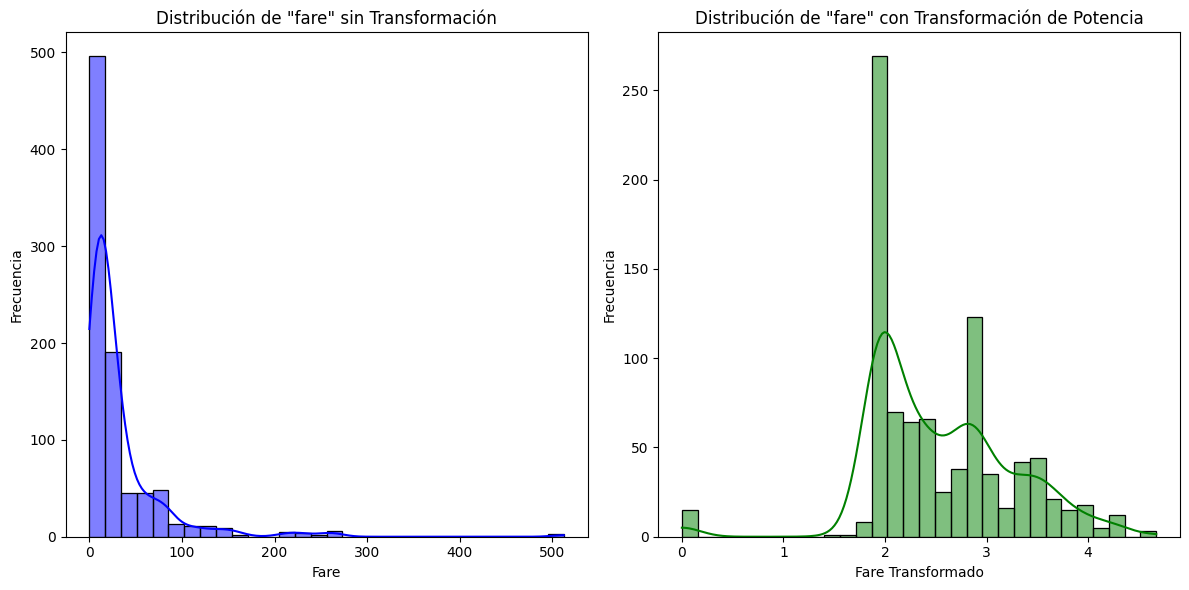

In [ ]:
# Crear dos histogramas, uno al lado del otro, para comparar las distribuciones
plt.figure(figsize=(12, 6))

# Histograma de 'fare' original
plt.subplot(1, 2, 1)
sns.histplot(df_yeo_johnson['fare'], kde=True, color='blue', bins=30)
plt.title('Distribución de "fare" sin Transformación')
plt.xlabel('Fare')
plt.ylabel('Frecuencia')

# Histograma de 'fare_transformed'
plt.subplot(1, 2, 2)
sns.histplot(df_yeo_johnson['fare_transformed'], kde=True, color='green', bins=30)
plt.title('Distribución de "fare" con Transformación de Potencia')
plt.xlabel('Fare Transformado')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Inconsistencia en el Formato
Las inconsistencias en el formato ocurren cuando los datos no están registrados de manera uniforme. Esto puede incluir fechas en diferentes formatos, texto con mayúsculas y minúsculas inconsistentes, o diferentes unidades de medida.


In [ ]:
import pandas as pd
import numpy as np

# Crear un DataFrame con inconsistencias
data = {
    'id': ['001', '002', '003', '004'],  # ID numérico pero en formato de string
    'age': ['25', 'thirty-two', '40.0', '22 years'],  # Números como texto, con palabras o unidades
    'salary': [50000, '55,000', '60.000', '$70,000'],  # Números con diferentes formatos y símbolos
    'join_date': ['2020-01-01', '02-24-2021', 'March 5, 2022', '2023/13/01'],  # Fechas en diferentes formatos, algunas inválidas
    'department': ['sales', 'HR', ' hr ', 'IT'],  # Inconsistencias en mayúsculas y espacios adicionales
}

df_inconsistencias= pd.DataFrame(data)

# Mostrar el DataFrame con inconsistencias
print("DataFrame con inconsistencias:")
print(df_inconsistencias)


DataFrame con inconsistencias:
    id         age   salary      join_date department
0  001          25    50000     2020-01-01      sales
1  002  thirty-two   55,000     02-24-2021         HR
2  003        40.0   60.000  March 5, 2022        hr 
3  004    22 years  $70,000     2023/13/01         IT


In [ ]:
df_titanic1.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0.0,2.0,male,27.000000,0.0,0.0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1.0,1.0,female,19.000000,0.0,0.0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0.0,3.0,female,23.259681,1.0,2.0,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1.0,1.0,male,26.000000,0.0,0.0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0.0,3.0,male,32.000000,0.0,0.0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


### Normalización de Datos en Aprendizaje Automático

La normalización de datos es un paso crucial en el preprocesamiento para asegurar que los modelos de aprendizaje automático funcionen de manera efectiva. La normalización ajusta las escalas de los datos para que todas las características contribuyan de manera equitativa al modelo. Esto es especialmente importante en algoritmos sensibles a la escala, como los basados en distancias.

#### ¿Por qué es importante la normalización?

- **Equilibrio en la influencia de las características**: Cuando los datos tienen diferentes escalas (por ejemplo, ingresos en miles y edades en años), las características con valores más grandes pueden dominar y sesgar el modelo. La normalización pone todas las características en una escala similar.
- **Convergencia más rápida**: En algoritmos de optimización como el descenso de gradiente, la normalización puede ayudar a que el algoritmo converja más rápido y con mayor precisión.
- **Mejora en el rendimiento**: Modelos como K-Nearest Neighbors (KNN), Support Vector Machines (SVM), y redes neuronales pueden mejorar su rendimiento con datos normalizados.

### Ejemplo de Normalización

Se va utilizar un conjunto de datos para ilustrar cómo aplicar la normalización en Python. Para ello se va a utilizar la biblioteca `sklearn`.

**`load_iris`** es una función que carga el conjunto de datos Iris, que es un conjunto de datos comúnmente utilizado en la comunidad de aprendizaje automático. Contiene características como el largo y ancho de sépalos y pétalos de tres especies de iris.



#### 1. Estandarización de los datos

En la estandarización, los datos son transformados para que tengan una media de 0 y una desviación estándar de 1. Esto es útil cuando se quiere que cada característica contribuya por igual en el modelado, independientemente de su escala original.

**`StandardScaler`**, es una herramienta para estandarizar características al restar la media y dividir por la desviación estándar de cada característica.

$$\mathbf{x}_{new} = \frac{\mathbf{x} - \mu}{\sigma}$$


In [ ]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Cargar el dataset Iris que es utilizada para problemas de aprendizaje automatico
data = load_iris()
df_iris = pd.DataFrame(data.data, columns=data.feature_names)

# Mostrar las primeras filas del dataset original
print("Dataset original:")
print(df_iris.head())

# Estandarización de los datos (media = 0, desviación estándar = 1)
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_iris),  columns=df_iris.columns)

# Mostrar las primeras filas del dataset estandarizado
print("\nDataset estandarizado:")
print(df_standardized.head())


Dataset original:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset estandarizado:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


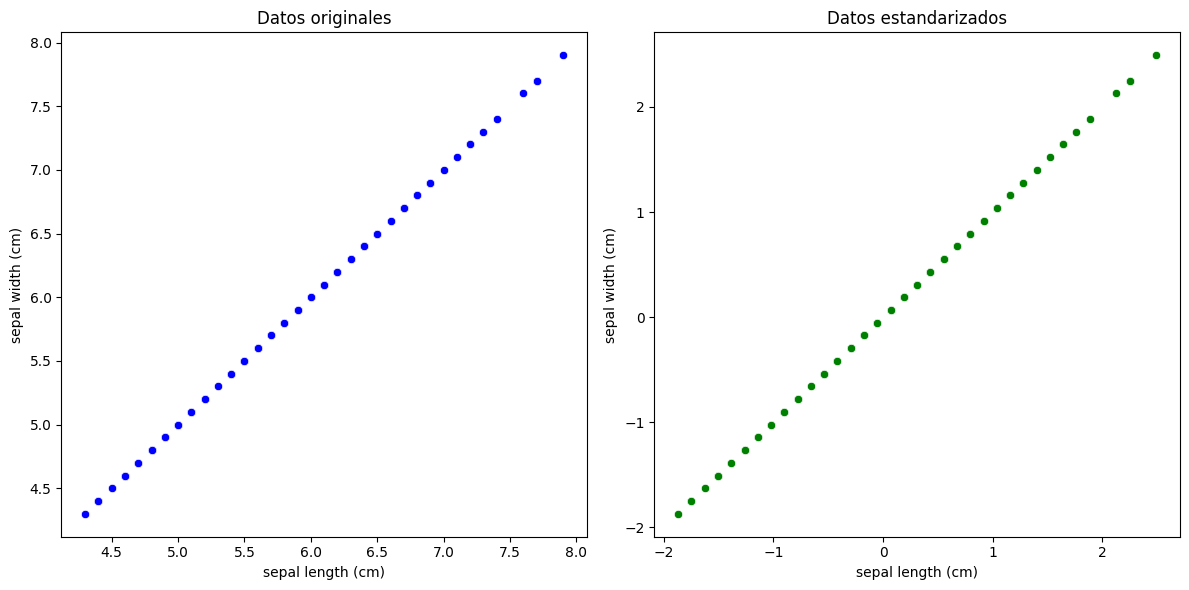

In [ ]:
# Crear dos scatterplot, uno al lado del otro, para comparar las distribuciones
plt.figure(figsize=(12, 6))

# Original
plt.subplot(1, 2, 1)
sns.scatterplot(df_iris, x= df_iris['sepal length (cm)'], y= df_iris['sepal length (cm)'], color='blue')
plt.title('Datos originales')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

# Escalado
plt.subplot(1, 2, 2)
sns.scatterplot(df_standardized, x= df_standardized['sepal length (cm)'], y= df_standardized['sepal length (cm)'], color='green')
plt.title('Datos estandarizados')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

plt.tight_layout()
plt.show()

### 2. Normalización Min-Max

Este método escala los datos para que se ajusten dentro de un rango específico, generalmente entre 0 y 1. Es particularmente útil cuando queremos mantener las relaciones proporcionales entre las características.

**`MinMaxScaler`** crea un transformador que normaliza los datos de manera que todas las características estarán en un rango [0, 1].

$$\mathbf{x}_{new} = \frac{\mathbf{x} - x_{min}}{x_{max} - x_{min}} \cdot (max - min) + min $$


In [ ]:
# Importar librerías necesarias
from sklearn.preprocessing import MinMaxScaler

# Normalización min-max (rango [0, 1])
scaler_2= MinMaxScaler()
df_normalize_2 = pd.DataFrame(scaler_2.fit_transform(df_iris),  columns=df_iris.columns)

# Mostrar las primeras filas del dataset normalizado
print("\nDataset normalizado (Min-Max):")
print(df_normalize_2.head())


Dataset normalizado (Min-Max):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.625000           0.067797          0.041667
1           0.166667          0.416667           0.067797          0.041667
2           0.111111          0.500000           0.050847          0.041667
3           0.083333          0.458333           0.084746          0.041667
4           0.194444          0.666667           0.067797          0.041667


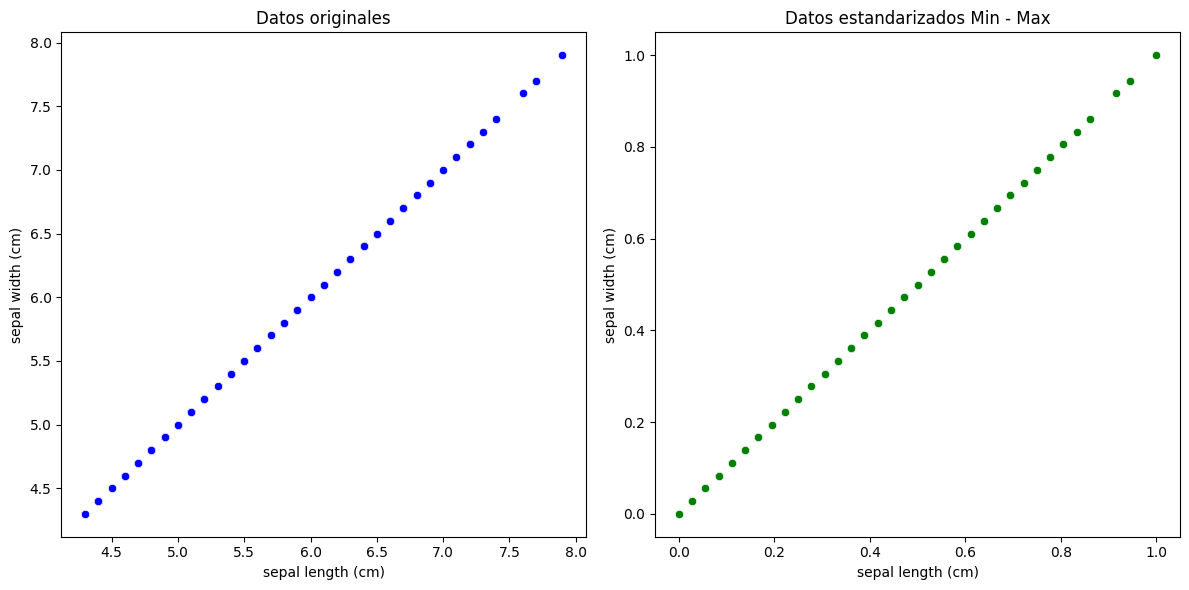

In [ ]:
# Crear dos scatterplot, uno al lado del otro, para comparar las distribuciones
plt.figure(figsize=(12, 6))

# Original
plt.subplot(1, 2, 1)
sns.scatterplot(df_iris, x= df_iris['sepal length (cm)'], y= df_iris['sepal length (cm)'], color='blue')
plt.title('Datos originales')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

# Min - Max
plt.subplot(1, 2, 2)
sns.scatterplot(df_normalize_2, x= df_normalize_2['sepal length (cm)'], y= df_normalize_2['sepal length (cm)'], color='green')
plt.title('Datos estandarizados Min - Max')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

plt.tight_layout()
plt.show()


#### 1. Esclado Robusto

* Resta la mediana, escala entre los cuantiles $q_{25}$ y $q_{75}$.
* La nueva característica tiene mediana 0, $q_{25}=-1$ y $q_{75}=1$.
* Similar al escalador estándar, pero ignora los valores atípicos.


In [ ]:
# Importar librerías necesarias
from sklearn.preprocessing import RobustScaler

# Normalización min-max (rango [0, 1])
scaler_3= RobustScaler()
df_normalized_3 = pd.DataFrame(scaler_3.fit_transform(df_iris), columns=df_iris.columns)

# Mostrar las primeras filas del dataset normalizado
print("\nDataset normalizado (Robust Scaler):")
print(df_normalized_3.head())


Dataset normalizado (Robust Scaler):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.538462               1.0          -0.842857         -0.733333
1          -0.692308               0.0          -0.842857         -0.733333
2          -0.846154               0.4          -0.871429         -0.733333
3          -0.923077               0.2          -0.814286         -0.733333
4          -0.615385               1.2          -0.842857         -0.733333


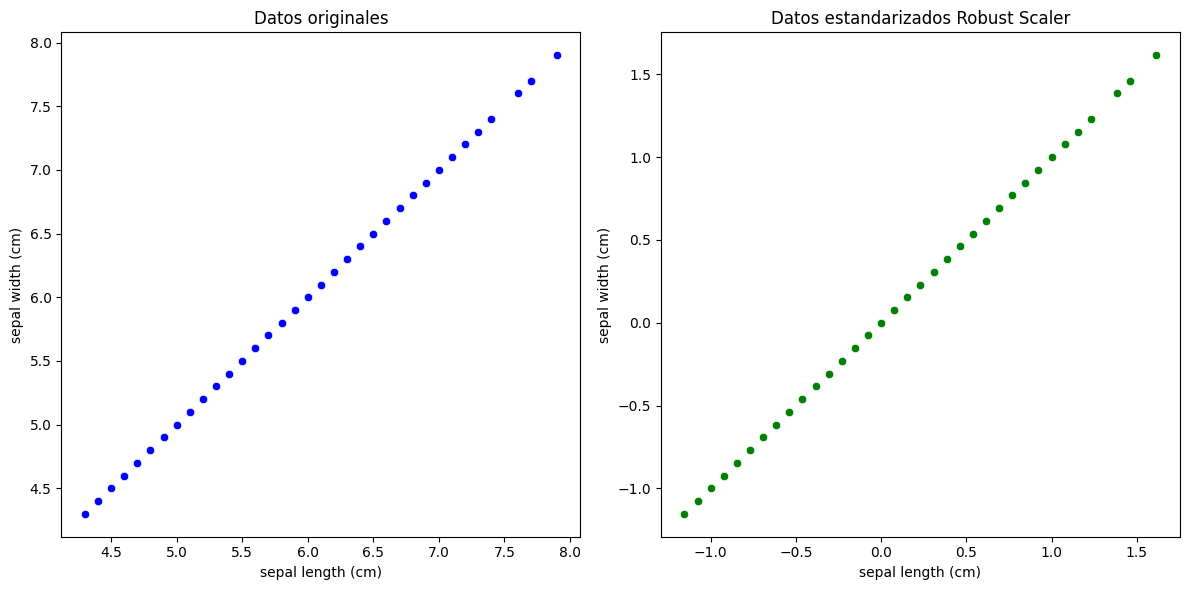

In [ ]:
# Crear dos scatterplot, uno al lado del otro, para comparar las distribuciones
plt.figure(figsize=(12, 6))

# Original
plt.subplot(1, 2, 1)
sns.scatterplot(df_iris, x= df_iris['sepal length (cm)'], y= df_iris['sepal length (cm)'], color='blue')
plt.title('Datos originales')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

# Robust Scaler
plt.subplot(1, 2, 2)
sns.scatterplot(df_normalized_3, x= df_normalized_3['sepal length (cm)'], y= df_normalized_3['sepal length (cm)'], color='green')
plt.title('Datos estandarizados Robust Scaler')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import Normalizer

# Asegura que los valores de las características de cada punto (cada fila) sumen 1 (norma L1)

scaler_4=Normalizer(norm='l1')

df_normalized_4 = pd.DataFrame(scaler_4.fit_transform(df_iris), columns=df_iris.columns)

# Mostrar las primeras filas del dataset normalizado
print("\nDataset normalizado (Robust Scaler):")
print(df_normalized_4.head())


Dataset normalizado (Robust Scaler):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.500000          0.343137           0.137255          0.019608
1           0.515789          0.315789           0.147368          0.021053
2           0.500000          0.340426           0.138298          0.021277
3           0.489362          0.329787           0.159574          0.021277
4           0.490196          0.352941           0.137255          0.019608


In [ ]:
# Sumar las filas del dataset normalizado
df_normalized_4.sum(axis=1)

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
145,1.0
146,1.0
147,1.0
148,1.0


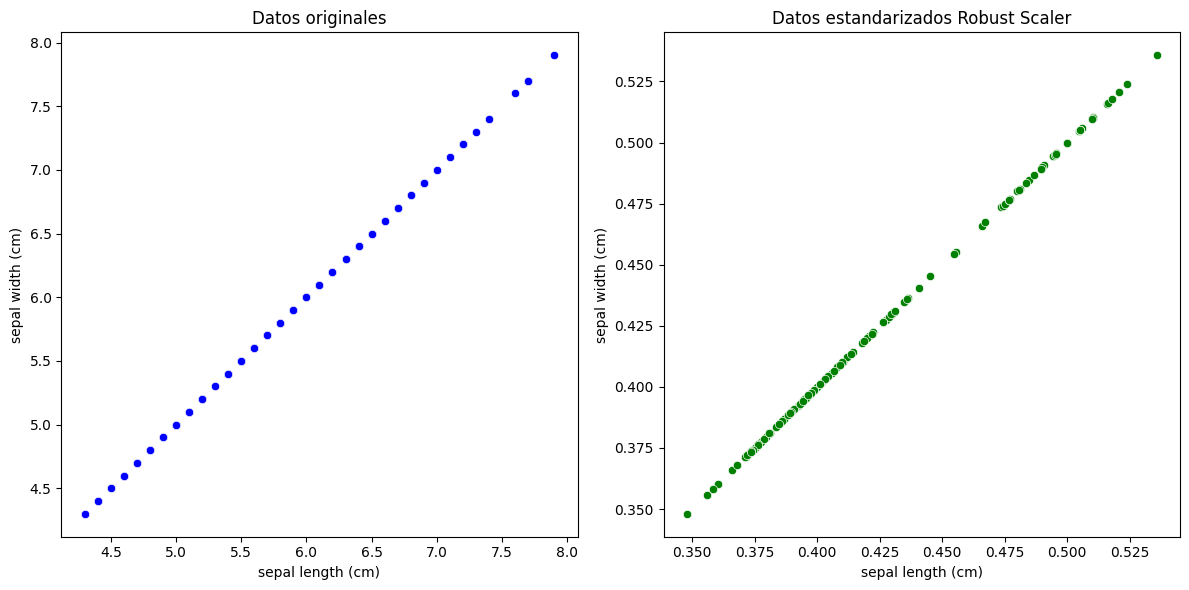

In [ ]:
# Crear dos scatterplot, uno al lado del otro, para comparar las distribuciones
plt.figure(figsize=(12, 6))

# Original
plt.subplot(1, 2, 1)
sns.scatterplot(df_iris, x= df_iris['sepal length (cm)'], y= df_iris['sepal length (cm)'], color='blue')
plt.title('Datos originales')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

# Robust Scaler
plt.subplot(1, 2, 2)
sns.scatterplot(df_normalized_4, x= df_normalized_4['sepal length (cm)'], y= df_normalized_4['sepal length (cm)'], color='green')
plt.title('Datos estandarizados Robust Scaler')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

plt.tight_layout()
plt.show()

Veamos un ejemplo con una base de datos mayor. Lo mas importante de este ejemplo es que debemos tener en cuenta que los parametros que requieren los escaladores,  como son los quantiles, el min y el max, la media, la media entre otros, deben ser aprendidos de los datos de entrenamiento y no deben ser aprendidos de toda la base de datos.

Por lo anterior, observa que la base de datos debe ser primero dividida entre entrenamiento y test. Los datos de entrenamiento servirán para ajustar a los escladores y luego, los parametros aprendidos serán usados para hacer la correspondiente transformación en los datos de training y los datos de test.

Con atención intenta observar esta discusión en el siguiente código:

In [ ]:
# from sklearn.datasets import load_boston
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor

# Cargar el dataset California Housing
housing = fetch_california_housing()
housing.DESCR.split('\n')


['.. _california_housing_dataset:',
 '',
 'California Housing dataset',
 '--------------------------',
 '',
 '**Data Set Characteristics:**',
 '',
 '    :Number of Instances: 20640',
 '',
 '    :Number of Attributes: 8 numeric, predictive attributes and the target',
 '',
 '    :Attribute Information:',
 '        - MedInc        median income in block group',
 '        - HouseAge      median house age in block group',
 '        - AveRooms      average number of rooms per household',
 '        - AveBedrms     average number of bedrooms per household',
 '        - Population    block group population',
 '        - AveOccup      average number of household members',
 '        - Latitude      block group latitude',
 '        - Longitude     block group longitude',
 '',
 '    :Missing Attribute Values: None',
 '',
 'This dataset was obtained from the StatLib repository.',
 'https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html',
 '',
 'The target variable is the median house value for

In [ ]:
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['MEDV'] = housing.target

In [ ]:
from sklearn.model_selection import train_test_split
# Separar características y etiquetas
X_housing = df_housing.drop('MEDV', axis=1)
y_housing = df_housing['MEDV']

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)


In [ ]:
from sklearn.metrics import mean_squared_error
# Modelo KNN SIN normalización
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_housing, y_train_housing)


y_pred_housing = knn.predict(X_test_housing)


mse_without_scaling = mean_squared_error(y_test_housing, y_pred_housing)

print("Resultados del modelo KNN sin normalización:")
print("MSE:", mse_without_scaling)



Resultados del modelo KNN sin normalización:
MSE: 1.1186823858768293


In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalizar los datos utilizando StandardScaler
scaler_housing = StandardScaler()


X_train_housing_scaled = scaler_housing.fit_transform(X_train_housing)


X_test_housing_scaled = scaler_housing.transform(X_test_housing)

# Modelo KNN CON normalización

knn_scaled = KNeighborsRegressor(n_neighbors=5)

knn_scaled.fit(X_train_housing_scaled, y_train_housing)


y_pred_housing_scaled = knn_scaled.predict(X_test_housing_scaled)

mse_with_scaling = mean_squared_error(y_test_housing, y_pred_housing_scaled)

print("\nResultados del modelo KNN con normalización:")
print("MSE:", mse_with_scaling)


Resultados del modelo KNN con normalización:
MSE: 0.4324216146043236


En este ejemplo se muestra que la normalización de las características utilizando **StandardScaler** en el modelo KNeighborsRegressor resultó en una reducción significativa del Mean Squared Error (MSE) de 1.118 a 0.432. Este resultado comprueba la importancia de la normalización en algoritmos que dependen de distancias,  mejorando así la precisión del modelo.


### Transformación de Datos Categóricos a Numéricos

En el contexto de ciencia de datos, las variables categóricas son aquellas que representan datos cualitativos. Estas variables no poseen un orden intrínseco (por ejemplo, colores, tipos de productos, etc.) o si lo poseen, su interpretación no está basada en una escala numérica. Dado que muchos algoritmos de aprendizaje automático (machine learning) trabajan con datos numéricos, es necesario transformar estas variables categóricas en un formato que pueda ser entendido y procesado por estos algoritmos. Este proceso se conoce como **codificación de variables categóricas**.

#### Codificación de Variables Categóricas: Transformación a Variables Numéricas

**1. Codificación One-Hot (One-Hot Encoding):**

La **codificación one-hot** es una de las técnicas más comunes para transformar variables categóricas en variables numéricas. Cada categoría de la variable categórica se convierte en una nueva columna binaria (dummy variable) con valores de 0 o 1.

- **0** indica la ausencia de la categoría en la observación.
- **1** indica la presencia de la categoría en la observación.


Si tenemos una variable `Color` con valores: `['Rojo', 'Verde', 'Azul']`, la codificación one-hot produciría:

| Rojo | Verde | Azul |
|------|-------|------|
|  1   |   0   |  0   |
|  0   |   1   |  0   |
|  0   |   0   |  1   |

In [ ]:
import seaborn as sns
import pandas as pd

# Cargar el dataset 'tips' desde Seaborn
df = sns.load_dataset('tips')

# Mostrar las primeras filas del dataset
print("Primeras filas del dataset 'tips':")
print(df.head())

# Identificar columnas categóricas
categorical_columns = df.select_dtypes(include=['category', 'object']).columns
print("\nColumnas categóricas:")
print(categorical_columns)


Primeras filas del dataset 'tips':
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Columnas categóricas:
Index(['sex', 'smoker', 'day', 'time'], dtype='object')


In [ ]:


# Transformar columnas categóricas a numéricas usando One-Hot Encoding (get dummies)


# Mostrar las primeras filas del dataset transformado con One-Hot Encoding
print("\nDataset transformado con One-Hot Encoding:")
print(df_one_hot.head())



Dataset transformado con One-Hot Encoding:
   total_bill   tip  size  sex_Female  smoker_No  day_Fri  day_Sat  day_Sun  \
0       16.99  1.01     2        True       True    False    False     True   
1       10.34  1.66     3       False       True    False    False     True   
2       21.01  3.50     3       False       True    False    False     True   
3       23.68  3.31     2       False       True    False    False     True   
4       24.59  3.61     4        True       True    False    False     True   

   time_Dinner  
0         True  
1         True  
2         True  
3         True  
4         True  


In [ ]:
df_one_hot.dtypes

,0
total_bill,float64
tip,float64
size,int64
sex_Female,bool
smoker_No,bool
day_Fri,bool
day_Sat,bool
day_Sun,bool
time_Dinner,bool


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Inicializar el OneHotEncoder
one_hot_encoder_sklearn = OneHotEncoder(sparse_output=False, drop='first')

# Aplicar One-Hot Encoding a las columnas categóricas
encoded_features = one_hot_encoder_sklearn.fit_transform(df[categorical_columns])

# Convertir el array resultante en un DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=one_hot_encoder_sklearn.get_feature_names_out(categorical_columns))

# Concatenar el DataFrame original (sin las columnas categóricas originales) con el DataFrame de las columnas one-hot encoded
df_tips_encoded_sklearn = pd.concat([df.drop(columns=categorical_columns), encoded_df], axis=1)

# Mostrar las primeras filas del DataFrame transformado
df_tips_encoded_sklearn.head()

,total_bill,tip,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,1.01,2,0.0,0.0,0.0,1.0,0.0,0.0
1,10.34,1.66,3,1.0,0.0,0.0,1.0,0.0,0.0
2,21.01,3.50,3,1.0,0.0,0.0,1.0,0.0,0.0
3,23.68,3.31,2,1.0,0.0,0.0,1.0,0.0,0.0
4,24.59,3.61,4,0.0,0.0,0.0,1.0,0.0,0.0


### 2. Codificación Ordinal (Ordinal Encoding)

En situaciones donde las categorías tienen un orden natural, como `Bajo`, `Medio`, `Alto`, se puede usar la **codificación ordinal**. En esta técnica, las categorías se asignan a números enteros, preservando el orden.


Si tenemos una variable `Tamaño` con valores: `['Pequeño', 'Mediano', 'Grande']`, la codificación ordinal podría ser:

| Pequeño | Mediano | Grande |
|---------|---------|--------|
|    1    |    2    |   3    |

Esto indica que `Pequeño` es menor que `Mediano`, y `Mediano` es menor que `Grande`.


**LabelEncoder** trabaja principalmente con una sola columna de etiquetas y se usa a menudo para la variable objetivo en modelos supervisados.

**OrdinalEncoder** está diseñado para trabajar con múltiples columnas de características categóricas en un DataFrame.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Inicializar el OrdinalEncoder
ordinal_encoder_tips = OrdinalEncoder()

df_ordinal_tips = df.copy()

# Aplicar OrdinalEncoder a las columnas categóricas


# Mostrar el DataFrame transformado
print("\nDataFrame simulado 'tips' transformado con Ordinal Encoding:")




DataFrame simulado 'tips' transformado con Ordinal Encoding:
     total_bill   tip  sex  smoker  day  time  size
0         16.99  1.01  0.0     0.0  2.0   0.0     2
1         10.34  1.66  1.0     0.0  2.0   0.0     3
2         21.01  3.50  1.0     0.0  2.0   0.0     3
3         23.68  3.31  1.0     0.0  2.0   0.0     2
4         24.59  3.61  0.0     0.0  2.0   0.0     4
..          ...   ...  ...     ...  ...   ...   ...
239       29.03  5.92  1.0     0.0  1.0   0.0     3
240       27.18  2.00  0.0     1.0  1.0   0.0     2
241       22.67  2.00  1.0     1.0  1.0   0.0     2
242       17.82  1.75  1.0     0.0  1.0   0.0     2
243       18.78  3.00  0.0     0.0  3.0   0.0     2

[244 rows x 7 columns]


In [ ]:
df_ordinal_tips.dtypes

,0
total_bill,float64
tip,float64
sex,float64
smoker,float64
day,float64
time,float64
size,int64


Supongamos que el usuario quiere elegir el orden de las categorias en el `ordinal_encoder`

In [ ]:
# Mostrar valores únicos para cada columna categórica
for col in categorical_columns:
    unique_values = df[col].unique()
    print(f"Valores únicos en la columna '{col}': {unique_values}")

Valores únicos en la columna 'sex': ['Female', 'Male']
Categories (2, object): ['Male', 'Female']
Valores únicos en la columna 'smoker': ['No', 'Yes']
Categories (2, object): ['Yes', 'No']
Valores únicos en la columna 'day': ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']
Valores únicos en la columna 'time': ['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']


In [ ]:
# Definir un orden personalizado para las categorías
custom_order = [['Male', 'Female'],  # Orden para 'sex'
                ['No', 'Yes'],       # Orden para 'smoker'
                ['Thur', 'Fri', 'Sat', 'Sun'],      # Orden para 'day'
                ['Lunch', 'Dinner']] # Orden para 'time'

# Inicializar el OrdinalEncoder con el orden personalizado


# Aplicar OrdinalEncoder a las columnas categóricas con el orden personalizado


# Mostrar el DataFrame transformado



DataFrame simulado 'tips' transformado con Ordinal Encoding:
     total_bill   tip  sex  smoker  day  time  size
0         16.99  1.01  1.0     0.0  3.0   1.0     2
1         10.34  1.66  0.0     0.0  3.0   1.0     3
2         21.01  3.50  0.0     0.0  3.0   1.0     3
3         23.68  3.31  0.0     0.0  3.0   1.0     2
4         24.59  3.61  1.0     0.0  3.0   1.0     4
..          ...   ...  ...     ...  ...   ...   ...
239       29.03  5.92  0.0     0.0  2.0   1.0     3
240       27.18  2.00  1.0     1.0  2.0   1.0     2
241       22.67  2.00  0.0     1.0  2.0   1.0     2
242       17.82  1.75  0.0     0.0  2.0   1.0     2
243       18.78  3.00  1.0     0.0  0.0   1.0     2

[244 rows x 7 columns]


In [ ]:
df_mapped = df.copy()

# Definir el mapeo personalizado para cada columna
custom_mapping = {
    'sex': {'Male': 1, 'Female': 0},
    'smoker': {'No': 0, 'Yes': 1},
    'day': {'Thur': 1, 'Fri': 2, 'Sat':3, 'Sun':4},
    'time': {'Lunch': 10, 'Dinner': 20}
}


# Aplicar el mapeo personalizado usando replace
df_mapped = df.replace(custom_mapping)

# Mostrar el DataFrame transformado
print("\nDataset transformado con mapeo personalizado:")
print(df_mapped)



Dataset transformado con mapeo personalizado:
     total_bill   tip sex smoker day time  size
0         16.99  1.01   0      0   4   20     2
1         10.34  1.66   1      0   4   20     3
2         21.01  3.50   1      0   4   20     3
3         23.68  3.31   1      0   4   20     2
4         24.59  3.61   0      0   4   20     4
..          ...   ...  ..    ...  ..  ...   ...
239       29.03  5.92   1      0   3   20     3
240       27.18  2.00   0      1   3   20     2
241       22.67  2.00   1      1   3   20     2
242       17.82  1.75   1      0   3   20     2
243       18.78  3.00   0      0   1   20     2

[244 rows x 7 columns]


In [ ]:
df_mapped.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


In [ ]:
df_mapped.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Pipelines

#### **¿Qué es el Data Leakage?**

El *data leakage* o "fuga de datos" es un problema crítico en el aprendizaje automático, que ocurre cuando la información del conjunto de prueba se filtra al conjunto de entrenamiento de alguna manera. Esto puede llevar a que un modelo tenga un rendimiento artificialmente alto en la fase de entrenamiento, pero un rendimiento deficiente en datos nunca antes vistos. El *data leakage* a menudo resulta en modelos que no generalizan bien, es decir, que no funcionan correctamente en datos nuevos, lo que los hace inútiles en aplicaciones reales.

##### **Ejemplo de Data Leakage:**

Imagina que estás construyendo un modelo para predecir si un cliente comprará un producto basado en ciertas características (por ejemplo, edad, historial de compras). Si accidentalmente incluyes información sobre una compra futura en el conjunto de entrenamiento, tu modelo aprenderá a predecir con una precisión muy alta en el conjunto de entrenamiento. Sin embargo, en datos reales, donde no tienes esa información futura, el rendimiento del modelo será mucho peor.

En el contexto de escalado de datos, un ejemplo de *data leakage* puede ocurrir cuando se aplica un escalado o normalización utilizando información de todo el conjunto de datos (incluyendo tanto el conjunto de entrenamiento como el de prueba). Esto hace que el modelo "vea" información del conjunto de prueba durante el entrenamiento.

#### **Visualización de Escalado Inapropiado de Datos:**

Vamos a visualizar cómo un escalado inapropiado puede afectar a los conjuntos de entrenamiento y prueba.

El código que compartiste tiene tres partes claves:
1. **Datos Originales**: Aquí, se muestra cómo están los datos antes de cualquier escalado.
2. **Datos Escalados Apropiadamente**: Se escalan los datos de entrenamiento y luego se transforma el conjunto de prueba usando los parámetros obtenidos del conjunto de entrenamiento.
3. **Datos Escalados Inapropiadamente**: Aquí, cada conjunto de datos se escala por separado, lo que causa problemas de inconsistencia.



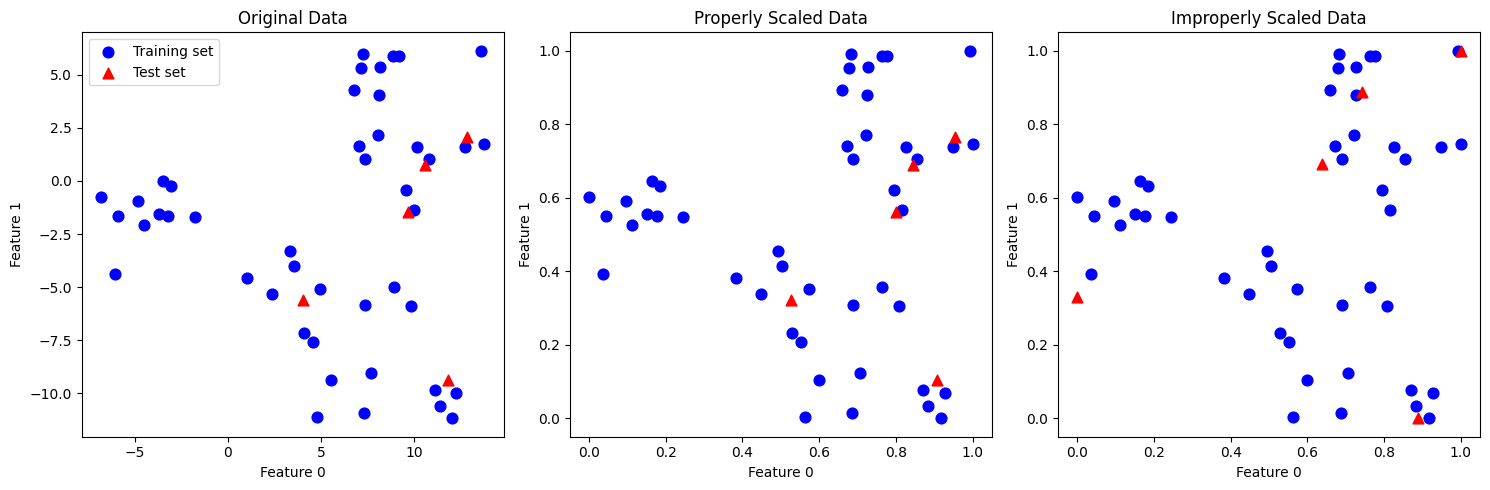

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Generar datos sintéticos
X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

# Crear un gráfico con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot de los datos originales
axes[0].scatter(X_train[:, 0], X_train[:, 1], c='b', label="Training set", s=60)
axes[0].scatter(X_test[:, 0], X_test[:, 1], marker='^', c='r', label="Test set", s=60)
axes[0].legend(loc='upper left')
axes[0].set_title("Original Data")

# Escalar los datos usando MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualizar los datos escalados correctamente
axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c='b', label="Training set", s=60)
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^', c='r', label="Test set", s=60)
axes[1].set_title("Properly Scaled Data")

# Escalar el conjunto de prueba por separado (Ejemplo de mala práctica)
test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

# Visualizar los datos escalados incorrectamente
axes[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c='b', label="Training set", s=60)
axes[2].scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1], marker='^', c='r', label="Test set", s=60)
axes[2].set_title("Improperly Scaled Data")

for ax in axes:
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
fig.tight_layout()
plt.show()

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/infoleak.png" alt="ml" style="width: 1500px;"/>

### **Pipelines en Scikit-Learn**

#### **¿Qué es un Pipeline en Machine Learning?**

En *Machine Learning*, un **pipeline** es una secuencia de pasos de procesamiento de datos que se ejecutan en un orden específico. Este flujo de trabajo automatiza el proceso de preprocesamiento, transformación, modelado y evaluación, permitiendo una mayor eficiencia y reduciendo la posibilidad de errores.

Los **pipelines** en Scikit-Learn son herramientas poderosas que permiten organizar y encadenar múltiples etapas de procesamiento de datos y modelos de manera ordenada. Esto es especialmente útil para tareas como la validación cruzada (*cross-validation*), la optimización de hiperparámetros y la eliminación de fugas de datos (*data leakage*).

#### **Beneficios de Usar Pipelines en Scikit-Learn:**

1. **Automatización del Flujo de Trabajo**: Los pipelines permiten encadenar varios pasos de preprocesamiento y modelado en un solo objeto, haciendo que el flujo de trabajo sea más fácil de manejar y reproducir.

2. **Reducción del Data Leakage**: Usar pipelines asegura que el proceso de preprocesamiento se ajuste únicamente a los datos de entrenamiento y luego se aplique a los datos de prueba, evitando la contaminación de datos.

3. **Facilita la Validación Cruzada y la Optimización de Hiperparámetros**: Con los pipelines, se pueden aplicar técnicas de validación cruzada y optimización de hiperparámetros de manera más eficiente, asegurando que todos los pasos del proceso se realicen en cada pliegue de los datos.

4. **Mejora la Legibilidad y Mantenimiento del Código**: Organizar los pasos en un pipeline hace que el código sea más limpio y fácil de entender, facilitando su mantenimiento y modificaciones futuras.



<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/07_pipelines.png" alt="ml" style="width: 600px;"/>

#### **Cómo Crear un Pipeline en Scikit-Learn:**

Un pipeline en Scikit-Learn se crea utilizando la clase `Pipeline` del módulo `sklearn.pipeline`. Aquí, los diferentes pasos (por ejemplo, escalado, selección de características, modelado) se definen en una lista de tuplas, donde cada tupla contiene un nombre para el paso y el objeto correspondiente (por ejemplo, un escalador o un clasificador).

##### **Ejemplo Básico de un Pipeline:**

A continuación, se presenta un ejemplo básico de cómo crear un pipeline para un flujo de trabajo de clasificación en Scikit-Learn:


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.metrics import classification_report

# Cargar un conjunto de datos
data = load_wine()
X, y = data.data, data.target

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear el pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Paso de escalado de datos
    ('pca', PCA(n_components=2)),  # Reducción de dimensionalidad con PCA
    ('classifier', RandomForestClassifier(random_state=42))  # Modelo de clasificación
])

# Entrenar el pipeline en el conjunto de entrenamiento
pipeline.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Evaluar el modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54





#### **Validación Cruzada con Pipelines:**

Scikit-Learn facilita la validación cruzada con pipelines utilizando la función `cross_val_score`. Esto permite evaluar el rendimiento de todo el flujo de trabajo, asegurando que todos los pasos se realizan en cada pliegue de los datos.

```python
from sklearn.model_selection import cross_val_score

# Realizar validación cruzada en el pipeline
scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())
```

En este ejemplo, la función `cross_val_score` divide los datos en 5 pliegues y entrena el pipeline en cada subconjunto de entrenamiento, evaluándolo en el subconjunto de prueba correspondiente.



#### **Optimización de Hiperparámetros con Pipelines:**

Los pipelines también son útiles para la optimización de hiperparámetros. Al usar un pipeline, se pueden ajustar los parámetros de todos los pasos del pipeline simultáneamente usando `GridSearchCV` o `RandomizedSearchCV`.

```python
from sklearn.model_selection import GridSearchCV

# Definir los hiperparámetros a buscar
param_grid = {
    'pca__n_components': [2, 3, 4],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20]
}

# Configurar GridSearchCV con el pipeline
grid_search = GridSearchCV(pipeline, param_grid, cv=5)

# Ajustar GridSearchCV
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)
```

En este ejemplo, `GridSearchCV` prueba todas las combinaciones de los parámetros especificados en `param_grid` y selecciona la mejor combinación basada en el rendimiento de validación cruzada.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir los hiperparámetros a buscar
param_grid = {
    'pca__n_components': [2, 3, 4],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20]
}

# Configurar GridSearchCV con el pipeline
grid_search = GridSearchCV(pipeline, param_grid, cv=5)

# Ajustar GridSearchCV
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Best parameters found:  {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'pca__n_components': 4}
Best cross-validation score:  0.9596666666666666


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

# Cargar el dataset Titanic
titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.frame




/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [ ]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
df.dtypes

,0
pclass,float64
survived,category
name,object
sex,category
age,float64
sibsp,float64
parch,float64
ticket,object
fare,float64
cabin,object


**Ejemplo Básico pipeline:**

Crear un pipeline simple que incluya el preprocesamiento (como escalado de características) y un modelo de clasificació

In [ ]:
# Seleccionar características relevantes y el target
X = df[['age', 'sibsp', 'parch']]
y = df['survived']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Crear un Pipeline básico
pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer()),  # Imputación de valores faltantes
    ('scaler', StandardScaler()),  # Escalado de características numéricas
    ('classifier', RandomForestClassifier(random_state=42))  # Modelo de clasificación
])

# Entrenar el Pipeline con los datos de entrenamiento
pipeline.fit(X_train, y_train)

# Evaluar el Pipeline en el conjunto de prueba
score = pipeline.score(X_test, y_test)
print(f"Test Accuracy: {score:.4f}")



Test Accuracy: 0.5954


Ejemplo basico ColumnTransform:



In [ ]:
# Seleccionar características relevantes y crear el target
X = df[['pclass', 'age', 'sex', 'sibsp', 'parch', 'embarked']]
y = df['survived']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definir columnas numéricas y categóricas
numeric_features = ['age', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked']

# Crear ColumnTransformer para transformar diferentes tipos de características
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# Aplicar el transformador a los datos de entrenamiento
preprocessed_data =pd.DataFrame(preprocessor.fit_transform(X_train), columns=preprocessor.get_feature_names_out())
print(preprocessed_data)


      num__age  num__sibsp  num__parch  cat__sex_female  cat__sex_male  \
0    -0.879039   -0.495964   -0.442432              0.0            1.0   
1     0.453610   -0.495964   -0.442432              0.0            1.0   
2    -0.808899   -0.495964    1.795376              1.0            0.0   
3     1.225143    0.456833   -0.442432              0.0            1.0   
4          NaN   -0.495964   -0.442432              0.0            1.0   
...        ...         ...         ...              ...            ...   
1042       NaN   -0.495964   -0.442432              1.0            0.0   
1043 -0.808899   -0.495964   -0.442432              1.0            0.0   
1044 -0.072436   -0.495964   -0.442432              0.0            1.0   
1045 -0.247784   -0.495964   -0.442432              1.0            0.0   
1046 -0.107505   -0.495964   -0.442432              1.0            0.0   

      cat__embarked_C  cat__embarked_Q  cat__embarked_S  cat__embarked_nan  
0                 0.0             

Ahora un ejemplo mayor combinando varias operaciones.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

# Cargar el dataset Titanic desde OpenML
titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.frame

# Seleccionar características relevantes y crear el target
X = df[['pclass', 'age', 'sex', 'sibsp', 'parch', 'embarked']]
y = df['survived']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [ ]:
# Definir las columnas numéricas y categóricas
numeric_features = ['age', 'sibsp', 'parch']
categorical_features_ordinal = ['pclass']  # Encodificación ordinal para pclass
categorical_features_onehot = ['sex', 'embarked']  # Encodificación OneHot para sex y embarked

# Crear el transformador de columnas para los datos numéricos y categóricos

# Crear el pipeline completo


# Entrenar el pipeline con los datos de entreonamiento
pipeline.fit(X_train, y_train)

# Evaluar el pipeline en el conjunto de prueba
score = pipeline.score(X_test, y_test)
print(f"Test Accuracy: {score:.4f}")

Test Accuracy: 0.7290


In [ ]:
# Acceder al ColumnTransformer dentro del pipeline
preprocessor_step = pipeline.named_steps['preprocessor']
print(preprocessor_step)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  IterativeImputer(random_state=0)),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'sibsp', 'parch']),
                                ('cat_ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder())]),
                                 ['pclass']),
                                ('cat_onehot',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                     

In [ ]:
# Acceder al paso de selección de características dentro del pipeline
feature_selection_step = pipeline.named_steps['feature_selection']
print(feature_selection_step)


SelectKBest(k=8)


In [ ]:
# Acceder al preprocesador (ColumnTransformer)
preprocessor = pipeline.named_steps['preprocessor']

# Acceder al imputador numérico dentro del preprocesador
imputer_numeric = preprocessor.named_transformers_['num'].named_steps['imputer']
print("Imputer Numérico:", imputer_numeric)

# Acceder al escalador numérico dentro del preprocesador
scaler = preprocessor.named_transformers_['num'].named_steps['scaler']
print("Scaler:", scaler)

# Transformar los datos de entrenamiento con el preprocesador para ver el resultado intermedio
X_train_transformed = preprocessor.transform(X_train)
print("Datos Transformados (Primeras 5 Filas):\n", X_train_transformed[:5])

# Acceder al clasificador (RandomForestClassifier)
classifier = pipeline.named_steps['classifier']
print("Clasificador:", classifier)

Imputer Numérico: IterativeImputer(random_state=0)
Scaler: StandardScaler()
Datos Transformados (Primeras 5 Filas):
 [[-0.96998556 -0.4959643  -0.44243194  2.          0.          1.
   0.          0.          1.        ]
 [ 0.49342103 -0.4959643  -0.44243194  1.          0.          1.
   0.          0.          1.        ]
 [-0.89296416 -0.4959643   1.79537599  0.          1.          0.
   0.          0.          1.        ]
 [ 1.34065643  0.45683317 -0.44243194  0.          0.          1.
   1.          0.          0.        ]
 [ 0.17344958 -0.4959643  -0.44243194  0.          0.          1.
   0.          0.          1.        ]]
Clasificador: RandomForestClassifier(random_state=42)
